<a href="https://colab.research.google.com/github/StormySpace/ICONML/blob/main/ICONML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.4/252.4 MB 5.5 MB/s eta 0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 3.3.0
    Uninstalling xgboost-3.3.0:
      Successfully uninstalled xgboost-3.3.0
Mounted at /content/drive
Test RMSE: 26.0904, R²: 0.9610, MAE: 13.3386, Bias: 1.8412
Train RMSE: 8.0111, R²: 0.9952, MAE: 5.1532, Bias: 0.0000


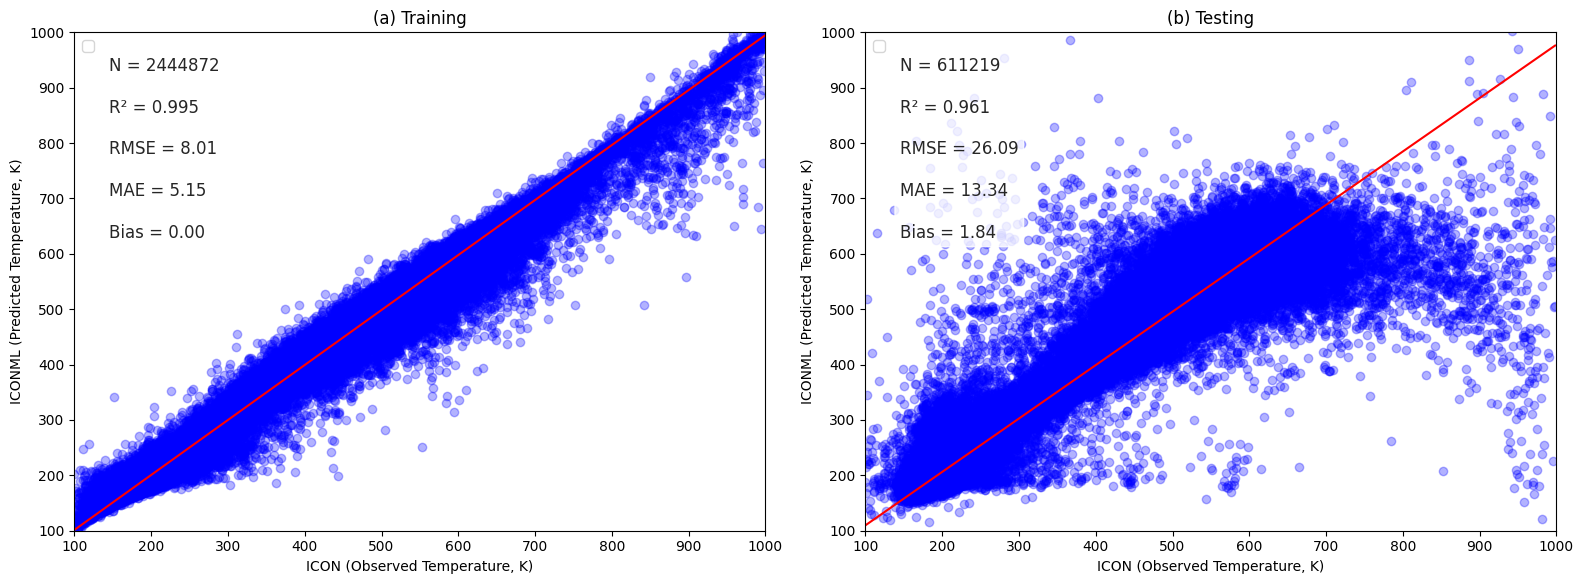

In [1]:
#ML for ICON
!pip install xgboost --upgrade
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import numpy as np
import pandas as pd
from google.colab import drive
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')
from math import sqrt
drive.mount('/content/drive')
icon1 = pd.read_csv('/content/drive/MyDrive/ICON/ICON_Temperature_Output.txt', sep='\t')
omni1 = pd.read_csv('/content/drive/MyDrive/ICON/omni_1hr_data_for_icon.txt', sep=r'\s+')
icon1.columns = icon1.columns.str.strip()
omni1.columns = omni1.columns.str.strip()
icon1['HR'] = icon1['HR'].astype(int)
omni1['HR'] = omni1['HR'].astype(int)
merged_final = pd.merge(icon1, omni1, on=['YEAR', 'DOY', 'HR'], how='inner')
total_rows = merged_final.shape[0]
split_index = int(0.8 * total_rows)

merged_final_train = merged_final.iloc[:split_index].reset_index(drop=True)
merged_final_test = merged_final.iloc[split_index:].reset_index(drop=True)

X_train = merged_final_train.drop(columns=[
    'AL', 'AU', 'YEAR', 'DOY', 'HR', 'temperature'
, 'mag_latitude', 'mag_longitude'
], errors='ignore')

y_train = merged_final_train['temperature']
X_test = merged_final_test.drop(columns=[
    'AL', 'AU', 'YEAR', 'DOY', 'HR', 'temperature'
, 'mag_latitude', 'mag_longitude'
], errors='ignore')

y_test = merged_final_test['temperature']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)
params = {
    'objective': 'reg:squarederror',
    'tree_method': 'hist',
    'max_depth': 12,
    'eval_metric': 'rmse',
}

num_boost_round = 150
model = xgb.train(params, dtrain, num_boost_round=num_boost_round)
y_pred_train = model.predict(dtrain)
y_pred_test = model.predict(dtest)
mse_test = mean_squared_error(y_test, y_pred_test)
mse_train = mean_squared_error(y_train, y_pred_train)

rmse_test = sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)
rmse_train = sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = r2_score(y_train, y_pred_train)

# Calculate MAE and Bias
mae_test = mean_absolute_error(y_test, y_pred_test)
mae_train = mean_absolute_error(y_train, y_pred_train)
bias_test = np.mean(y_pred_test - y_test)
bias_train = np.mean(y_pred_train - y_train)

# Fix negative zero display
bias_test = 0.0 if abs(bias_test) < 1e-10 else bias_test
bias_train = 0.0 if abs(bias_train) < 1e-10 else bias_train

print(f'Test RMSE: {rmse_test:.4f}, R²: {r2_test:.4f}, MAE: {mae_test:.4f}, Bias: {bias_test:.4f}')
print(f'Train RMSE: {rmse_train:.4f}, R²: {r2_train:.4f}, MAE: {mae_train:.4f}, Bias: {bias_train:.4f}')

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Function to plot true vs predicted temperature
def plot_scatter(ax, y_true, y_pred, title):
    ax.scatter(y_true, y_pred, alpha=0.3, color='blue')

    # Regression line
    y_true_reshaped = y_true.reshape(-1, 1)
    model = LinearRegression().fit(y_true_reshaped, y_pred)
    y_line = model.predict(y_true_reshaped)

    # Sort for clean line
    sorted_indices = np.argsort(y_true)
    ax.plot(y_true[sorted_indices], y_line[sorted_indices], color='red')

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    bias = np.mean(y_pred - y_true)

    # Fix negative zero display
    bias = 0.0 if abs(bias) < 1 else bias

    n = len(y_true)

    ax.set_title(f'{title}')
    ax.text(0.05, 0.95, f'N = {n}\n\nR² = {r2:.3f}\n\nRMSE = {rmse:.2f}\n\nMAE = {mae:.2f}\n\nBias = {bias:.2f}',
            transform=ax.transAxes, fontsize=12, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax.set_xlabel('ICON (Observed Temperature, K)')
    ax.set_ylabel('ICONML (Predicted Temperature, K)')
    ax.set_xlim(100, 1000)
    ax.set_ylim(100, 1000)
    ax.grid(False)
    ax.legend()

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
sns.set(style='whitegrid')

# Plot for training data
plot_scatter(axs[0], y_train.values, y_pred_train, '(a) Training')

# Plot for testing data
plot_scatter(axs[1], y_test.values, y_pred_test, '(b) Testing')

plt.tight_layout()

#output_path = '/content/drive/MyDrive/ICON/Fig3_rev.png'
#plt.savefig(output_path, dpi=300)
#print(f"Plot saved to: {output_path}")

plt.show()
